# Data Exploration - Yelp Dataset

This notebook explores the Yelp dataset for the Tourist Recommendation System.

In [1]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

from src.data import YelpDataLoader, TextPreprocessor, DataSampler
from src.config import get_config

# Setup
pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')
config = get_config()

## 1. Load the Data

In [2]:
# Initialize loader
loader = YelpDataLoader()

# Load a sample of the data (adjust limit as needed)
# For tourism, filter to relevant categories
tourism_categories = [
    "Restaurant", "Hotel", "Museum", "Park", "Bar",
    "Cafe", "Attraction", "Entertainment", "Shopping"
]

# Load with limit for exploration
data = loader.load_all(limit=10000, categories_filter=tourism_categories)

# Get stats
stats = loader.get_dataset_stats(data)
for name, info in stats.items():
    print(f"\n{name.upper()}:")
    print(f"  Count: {info['count']:,}")
    print(f"  Memory: {info['memory_mb']:.2f} MB")

Loading businesses: 10000it [00:00, 78982.97it/s]
Loading reviews: 10000it [00:00, 100468.63it/s]
Loading users: 10000it [00:00, 39667.21it/s]
Photo metadata not found: c:\Users\ewenl\draft-koko\notebooks\..\data\raw\photos.json\photos.json



BUSINESSES:
  Count: 5,989
  Memory: 6.46 MB

REVIEWS:
  Count: 5,825
  Memory: 4.99 MB

USERS:
  Count: 480
  Memory: 4.32 MB

PHOTOS:
  Count: 0
  Memory: 0.00 MB


## 2. Explore Business Data

In [3]:
businesses = data['businesses']
print(f"Columns: {businesses.columns.tolist()}")
businesses.head()

Columns: ['business_id', 'name', 'address', 'city', 'state', 'postal_code', 'latitude', 'longitude', 'stars', 'review_count', 'is_open', 'attributes', 'categories', 'hours']


,business_id,name,address,city,state,postal_code,latitude,longitude,stars,review_count,is_open,attributes,categories,hours
0,tUFrWirKiKi_TAnsVWINQQ,Target,5255 E Broadway Blvd,Tucson,AZ,85711,32.223236,-110.880452,3.5,22,0,"{'BikeParking': 'True', 'BusinessAcceptsCredit...","Department Stores, Shopping, Fashion, Home & G...","{'Monday': '8:0-22:0', 'Tuesday': '8:0-22:0', ..."
1,MTSW4McQd7CbVtyjqoe9mw,St Honore Pastries,935 Race St,Philadelphia,PA,19107,39.955505,-75.155564,4.0,80,1,"{'RestaurantsDelivery': 'False', 'OutdoorSeati...","Restaurants, Food, Bubble Tea, Coffee & Tea, B...","{'Monday': '7:0-20:0', 'Tuesday': '7:0-20:0', ..."
2,CF33F8-E6oudUQ46HnavjQ,Sonic Drive-In,615 S Main St,Ashland City,TN,37015,36.269593,-87.058943,2.0,6,1,"{'BusinessParking': 'None', 'BusinessAcceptsCr...","Burgers, Fast Food, Sandwiches, Food, Ice Crea...","{'Monday': '0:0-0:0', 'Tuesday': '6:0-22:0', '..."
3,n_0UpQx1hsNbnPUSlodU8w,Famous Footwear,"8522 Eager Road, Dierbergs Brentwood Point",Brentwood,MO,63144,38.627695,-90.340465,2.5,13,1,"{'BusinessAcceptsCreditCards': 'True', 'Restau...","Sporting Goods, Fashion, Shoe Stores, Shopping...","{'Monday': '0:0-0:0', 'Tuesday': '10:0-18:0', ..."
4,k0hlBqXX-Bt0vf1op7Jr1w,Tsevi's Pub And Grill,8025 Mackenzie Rd,Affton,MO,63123,38.565165,-90.321087,3.0,19,0,"{'Caters': 'True', 'Alcohol': 'u'full_bar'', '...","Pubs, Restaurants, Italian, Bars, American (Tr...",None


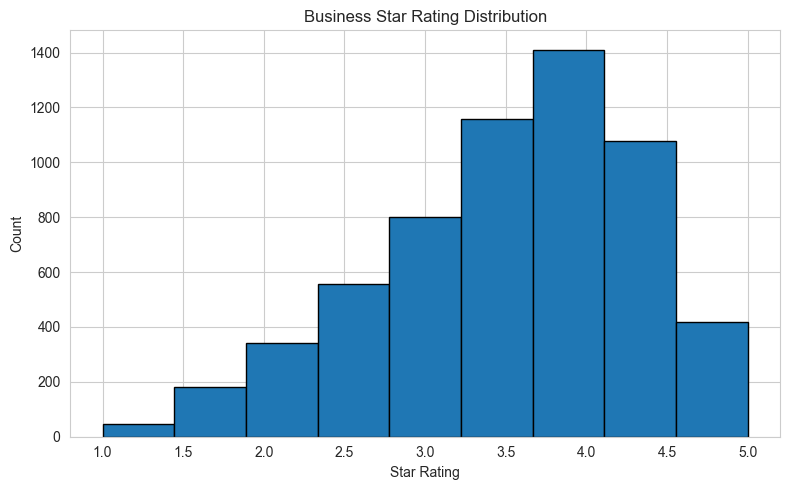

In [4]:
# Star rating distribution
if 'stars' in businesses.columns:
    fig, ax = plt.subplots(figsize=(8, 5))
    businesses['stars'].hist(bins=9, ax=ax, edgecolor='black')
    ax.set_xlabel('Star Rating')
    ax.set_ylabel('Count')
    ax.set_title('Business Star Rating Distribution')
    plt.tight_layout()
    plt.show()

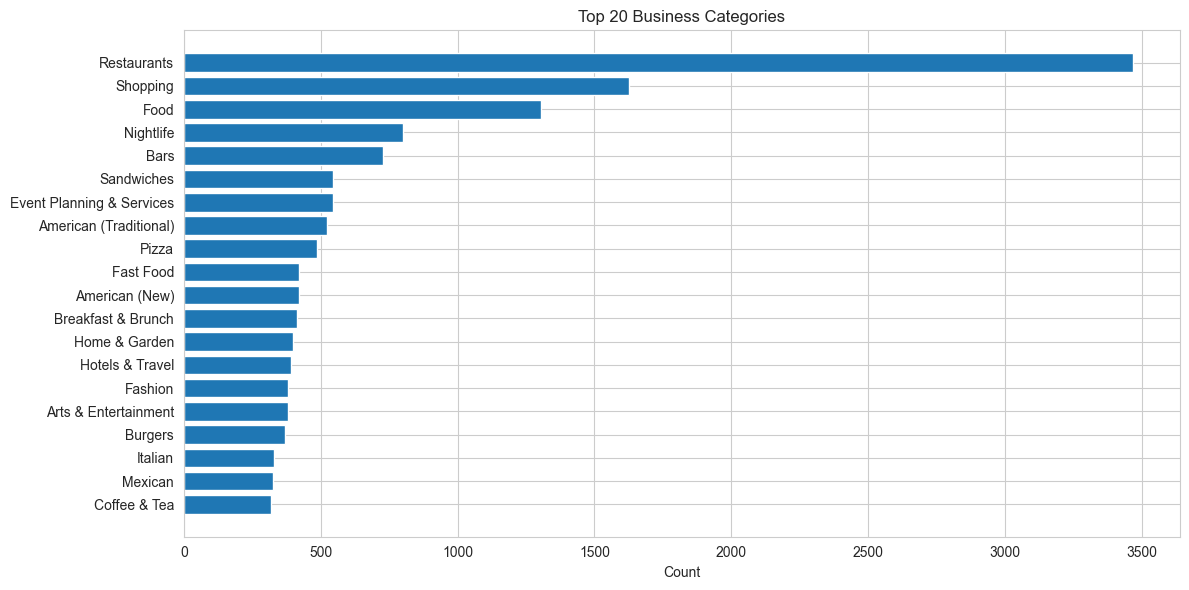

In [5]:
# Top categories
if 'categories' in businesses.columns:
    all_cats = []
    for cats in businesses['categories'].dropna():
        all_cats.extend([c.strip() for c in cats.split(',')])
    
    cat_counts = Counter(all_cats).most_common(20)
    
    fig, ax = plt.subplots(figsize=(12, 6))
    cats, counts = zip(*cat_counts)
    ax.barh(cats[::-1], counts[::-1])
    ax.set_xlabel('Count')
    ax.set_title('Top 20 Business Categories')
    plt.tight_layout()
    plt.show()

## 3. Explore Review Data

In [6]:
reviews = data['reviews']
print(f"Columns: {reviews.columns.tolist()}")
reviews.head()

Columns: ['review_id', 'user_id', 'business_id', 'stars', 'useful', 'funny', 'cool', 'text', 'date']


,review_id,user_id,business_id,stars,useful,funny,cool,text,date
0,KU_O5udG6zpxOg-VcAEodg,mh_-eMZ6K5RLWhZyISBhwA,XQfwVwDr-v0ZS3_CbbE5Xw,3.0,0,0,0,"If you decide to eat here, just be aware it is...",2018-07-07 22:09:11
1,AqPFMleE6RsU23_auESxiA,_7bHUi9Uuf5__HHc_Q8guQ,kxX2SOes4o-D3ZQBkiMRfA,5.0,1,0,1,"Wow! Yummy, different, delicious. Our favo...",2015-01-04 00:01:03
2,Sx8TMOWLNuJBWer-0pcmoA,bcjbaE6dDog4jkNY91ncLQ,e4Vwtrqf-wpJfwesgvdgxQ,4.0,1,0,1,Cute interior and owner (?) gave us tour of up...,2017-01-14 20:54:15
3,JrIxlS1TzJ-iCu79ul40cQ,eUta8W_HdHMXPzLBBZhL1A,04UD14gamNjLY0IDYVhHJg,1.0,1,2,1,I am a long term frequent customer of this est...,2015-09-23 23:10:31
4,6AxgBCNX_PNTOxmbRSwcKQ,r3zeYsv1XFBRA4dJpL78cw,gmjsEdUsKpj9Xxu6pdjH0g,5.0,0,2,0,Loved this tour! I grabbed a groupon and the p...,2015-01-03 23:21:18


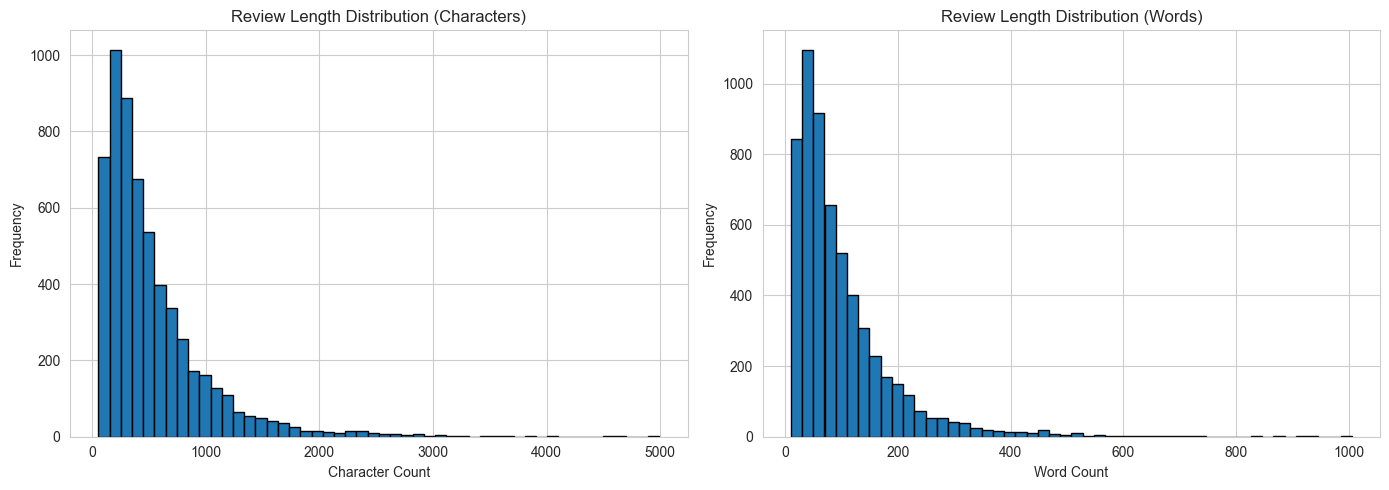

Average review length: 98.7 words
Median review length: 71.0 words


In [7]:
# Review length distribution
if 'text' in reviews.columns:
    reviews['text_length'] = reviews['text'].str.len()
    reviews['word_count'] = reviews['text'].str.split().str.len()
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    reviews['text_length'].hist(bins=50, ax=axes[0], edgecolor='black')
    axes[0].set_xlabel('Character Count')
    axes[0].set_ylabel('Frequency')
    axes[0].set_title('Review Length Distribution (Characters)')
    
    reviews['word_count'].hist(bins=50, ax=axes[1], edgecolor='black')
    axes[1].set_xlabel('Word Count')
    axes[1].set_ylabel('Frequency')
    axes[1].set_title('Review Length Distribution (Words)')
    
    plt.tight_layout()
    plt.show()
    
    print(f"Average review length: {reviews['word_count'].mean():.1f} words")
    print(f"Median review length: {reviews['word_count'].median():.1f} words")

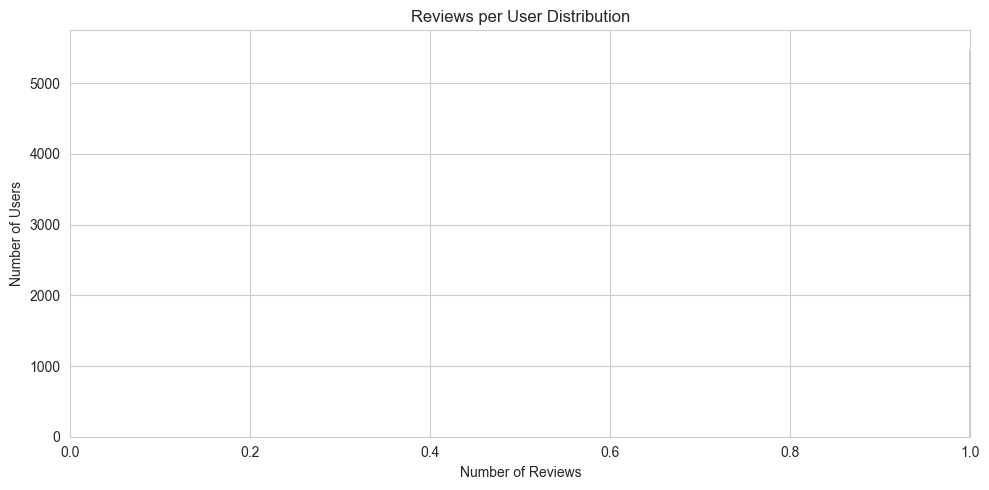

Average reviews per user: 1.03
Users with 5+ reviews: 1


In [8]:
# Reviews per user distribution
reviews_per_user = reviews['user_id'].value_counts()

fig, ax = plt.subplots(figsize=(10, 5))
reviews_per_user.hist(bins=50, ax=ax, edgecolor='black')
ax.set_xlabel('Number of Reviews')
ax.set_ylabel('Number of Users')
ax.set_title('Reviews per User Distribution')
ax.set_xlim(0, reviews_per_user.quantile(0.95))  # Limit to 95th percentile
plt.tight_layout()
plt.show()

print(f"Average reviews per user: {reviews_per_user.mean():.2f}")
print(f"Users with 5+ reviews: {(reviews_per_user >= 5).sum():,}")

## 4. Text Preprocessing Demo

In [9]:
preprocessor = TextPreprocessor()

# Sample some reviews and clean them
sample_reviews = reviews['text'].head(5).tolist()

for i, review in enumerate(sample_reviews):
    cleaned = preprocessor.clean_text(review)
    print(f"--- Review {i+1} ---")
    print(f"Original ({len(review)} chars): {review[:200]}...")
    print(f"Cleaned ({len(cleaned)} chars): {cleaned[:200]}...")
    print()

--- Review 1 ---
Original (513 chars): If you decide to eat here, just be aware it is going to take about 2 hours from beginning to end. We have tried it multiple times, because I want to like it! I have been to it's other locations in NJ ...
Cleaned (511 chars): if you decide to eat here, just be aware it is going to take about 2 hours from beginning to end. we have tried it multiple times, because i want to like it! i have been to it's other locations in nj ...

--- Review 2 ---
Original (243 chars): Wow!  Yummy, different,  delicious.   Our favorite is the lamb curry and korma.  With 10 different kinds of naan!!!  Don't let the outside deter you (because we almost changed our minds)...go in and t...
Cleaned (234 chars): wow! yummy, different, delicious. our favorite is the lamb curry and korma. with 10 different kinds of naan!!! don't let the outside deter you because we almost changed our minds ...go in and try some...

--- Review 3 ---
Original (534 chars): Cute interior and owner

In [10]:
# Process all reviews
reviews_clean = preprocessor.process_dataframe(reviews, text_column='text')
print(f"Cleaned {len(reviews_clean)} reviews")
reviews_clean[['text', 'clean_text']].head()

Cleaned 5825 reviews


,text,clean_text
0,"If you decide to eat here, just be aware it is...","if you decide to eat here, just be aware it is..."
1,"Wow! Yummy, different, delicious. Our favo...","wow! yummy, different, delicious. our favorite..."
2,Cute interior and owner (?) gave us tour of up...,cute interior and owner ? gave us tour of upco...
3,I am a long term frequent customer of this est...,i am a long term frequent customer of this est...
4,Loved this tour! I grabbed a groupon and the p...,loved this tour! i grabbed a groupon and the p...


## 5. Data Sampling Demo

In [11]:
sampler = DataSampler()

# Filter by activity
reviews_filtered = sampler.filter_by_activity(
    reviews_clean,
    min_user_reviews=1,
    min_business_reviews=1
)

print(f"After filtering: {len(reviews_filtered)} reviews")
print(f"Unique users: {reviews_filtered['user_id'].nunique()}")
print(f"Unique businesses: {reviews_filtered['business_id'].nunique()}")

After filtering: 5825 reviews
Unique users: 5639
Unique businesses: 2023


In [12]:
# Train/val/test split
train, val, test = sampler.train_val_test_split(reviews_filtered)

print(f"Train: {len(train)} ({len(train)/len(reviews_filtered)*100:.1f}%)")
print(f"Val: {len(val)} ({len(val)/len(reviews_filtered)*100:.1f}%)")
print(f"Test: {len(test)} ({len(test)/len(reviews_filtered)*100:.1f}%)")

Train: 4659 (80.0%)
Val: 583 (10.0%)
Test: 583 (10.0%)


## 6. Save Processed Data

In [13]:
from src.config.settings import PROCESSED_DATA_DIR

# Save processed datasets
PROCESSED_DATA_DIR.mkdir(parents=True, exist_ok=True)

train.to_parquet(PROCESSED_DATA_DIR / 'train_reviews.parquet', index=False)
val.to_parquet(PROCESSED_DATA_DIR / 'val_reviews.parquet', index=False)
test.to_parquet(PROCESSED_DATA_DIR / 'test_reviews.parquet', index=False)
businesses.to_parquet(PROCESSED_DATA_DIR / 'businesses.parquet', index=False)

print("Saved processed data to:", PROCESSED_DATA_DIR)

Saved processed data to: c:\Users\ewenl\draft-koko\notebooks\..\data\processed


## Next Steps

1. **Phase 2**: Train BERT MBTI classifier on user reviews
2. **Phase 3**: Apply BERTopic for venue topic modeling
3. **Phase 4**: Build heterogeneous graph and train GNN